# Homework 4
## ME 326: Collaborative Robotics
### Stanford University

## NOTE - Run this script with CUDA (GPU)
You are encouraged to run this script with GPU enabled. If you are using Google Colab, you can select a GPU runtime. By selecting `Runtime' then `Change session runtype' you can ensure GPU is the hardware accelerator [tutorial](https://www.tutorialspoint.com/google_colab/google_colab_using_free_gpu.htm).

In [1]:
# make sure to install the packages below!

from __future__ import print_function
import argparse
import torch
from torch import nn, optim
from torch.nn import functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image
import torch.utils.data

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os #for making a results directory in problem 2
import math
import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as T

## Readme:
This homework leverages an accompanying MINST dataset. The following lines pull down this well-known dataset:

In [2]:
import torchvision.datasets as datasets
mnist_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=None)

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.68MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 421kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.7MB/s]


In [4]:
data_path = 'data' #run this if you are running this locally and the data folder is at the same directory as the notebook

## Problem 1: LSTM Sequence Prediction

>*Figures in this problem are referenced/imported from this toward data science article: [Illustrated Guide to LSTM’s and GRU’s: A step by step explanation](https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21) (and is encouraged for further reading)*

>Check out this [video](https://youtu.be/8HyCNIVRbSU) for a video summary of how LSTM's work:
[![Illustrated Guide to LSTM's and GRU's: A step by step explanation](https://img.youtube.com/vi/8HyCNIVRbSU/0.jpg)](https://www.youtube.com/watch?v=8HyCNIVRbSU)

## Sequential Data
In some problems, it is beneficial to recognize a pattern that emerges from a sequence of data. If there are underlying principles driving behavior, they may be best interpreted by observing the system over time then using those observations to extrapolate to expected future sequence states.

This leads to the study of **Recurrent Neural Network**(RNN) which are designed specifically to work with sequential data (could be time dependent or time independent). The key components of the general architecture of a RNN is the input vector $x$ (which was observed or known) being fed into the RNN, and the RNN maintains *hidden* states $h$ which serve as "*memory*" for the network as it processes new input and/or predicts future outputs. A key challenge in such a network is the question: *"what information is most important to remember?"*

Long-Short Term Memory (LSTM) networks (a type of RNN) are one answer to this question, with the ability to *forget*, *input new information into memory*, provide both a *new output (hidden state)* available to external query as well as *maintain an updated internal state (cell state)* for future memory iterations.

While it will not be discussed further in this homework, the student should be aware of another option - [Attention Networks](https://towardsdatascience.com/attention-in-neural-networks-e66920838742) which observe a sequence and determine what is the most important information to *pay attention to* in order to make some prediction or estimation.

For the LSTM, the structure is shown here and consists of a forget gate, cell state, input gate and output gate. For completeness, a Gated Recurrent Unit (GRU) is shown (very similar to LSTM with a few less 'control' handles). 

<div>
<img src="https://miro.medium.com/max/1400/1*yBXV9o5q7L_CvY7quJt3WQ.png" width="600"/>
</div>

A basic RNN cell takes in a hidden state and input state, passes it through a Tanh function and outputs a new hidden state

<div>
<img src="https://miro.medium.com/max/1400/1*WMnFSJHzOloFlJHU6fVN-g.gif" width="600"/>
</div>
where the Tanh activation serves to map the values between -1 and 1
<div>
<img src="https://miro.medium.com/max/1400/1*iRlEg1GBKRzGTre5aOQUCg.gif" width="600"/>
</div>

The architecture of an LSTM cell is shown below:

<div>
<img src="https://miro.medium.com/max/1400/1*0f8r3Vd-i4ueYND1CUrhMA.png" width="600"/>
</div>

with the key attribute being its various gates. The *cell state* is designed to carry relevant information throughout iterations of the sequence serving as a 'transport highway' of information. As the cell state progresses, it must be informed by new information and focus on what is important through the use of *gates*. The *gates* leverage sigmoid activation functions which compress continuous input information between 0 and 1: 

<div>
<img src="https://miro.medium.com/max/1400/1*rOFozAke2DX5BmsX2ubovw.gif" width="600"/>
</div>

The different gates are as follows: 
### Forget Gate
The *forget gate* decides which information should be 'thrown away' or kept and this is done by passing added previous $h$ and current $x$ information through a sigmoid function where values closer to 0 implies to *forget* and values closer to 1 indicate to *keep*
<div>
<img src="https://miro.medium.com/max/1400/1*GjehOa513_BgpDDP6Vkw2Q.gif" width="600"/>
</div>

### Input Gate
The *input gate* updates the cell state with new information. This is achieved by passing added hidden and current state through a sigmoid and tanh functions respectively then multiplying the outputs. The sigmoid function effectively determines how important each value is (0 non-important; 1 important). The tanh function serves to regulate the network by mapping the values between -1 and 1. Because it is a pointwise multiplication, the sigmoid directly determines which values to keep from the tanh output.
<div>
<img src="https://miro.medium.com/max/1400/1*TTmYy7Sy8uUXxUXfzmoKbA.gif" width="600"/>
</div>

### Cell State
Given outputs from the *forget and input gates* we can now update the internal *cell state* by first multiplying by the forget vector (which could possibly cause dropping of values in the cell state if forget vector has values close to zero). Then the output from the cell state and forget vector is then point-wise added to the outcome of the input gate which updates the cell state with values that the network deems relevant.
<div>
<img src="https://miro.medium.com/max/1400/1*S0rXIeO_VoUVOyrYHckUWg.gif" width="600"/>
</div>

### Output Gate
Finally, for the *output gate* which determines what the next hidden state will be, we must first take the previous hidden state and input and pass it through a sigmoid function (for importance) then multiply it by the newest cell state passed through a tanh function (regularized), and this determines what information the hidden state should carry. **The final output (to the world outside the LSTM cell) is the hidden state**. 
<div>
<img src="https://miro.medium.com/max/1400/1*VOXRGhOShoWWks6ouoDN3Q.gif" width="600"/>
</div>


In summary, the forget gate decides whats relevant from prior steps; the input gate decides what new information is relvant to add to the cell state and the output gate determines what the next hidden state should become.

**Python Psuedo Code:**

<div>
<img src="https://miro.medium.com/max/1400/1*p2yXhtxmYflEUrTC1rCoUA.png" width="300"/>
</div>

Pytorch [documentation on LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTMCell.html).

## Your Problem: predicting a sequence
In this problem, you will predict the next values in a sequence function given history of values by training an LSTM. 

Unlike previous scripts, your code will be to fill in components of a class that will be used by support code to track and predict a series of sine curves.

You will generate two LSTM cells whose hidden state dimension is 51 $h_{51}, c_{51}$, and your inputs will flow as follows: 

$$x \rightarrow \text{LSTM}_1(x, (h_{1,t},c_{1,t})) \rightarrow (h_{1,t},c_{1,t}) \rightarrow \text{LSTM}_2(h_{1,t},(h_{2,t},c_{2,t})) \rightarrow (h_{2,t},c_{2,t}) \rightarrow y = Ah_{2,t} + b \rightarrow y $$ 

Your function for forward pass will take the training data, learning rate, training steps, and number of "future" steps to extrapolate into the future. 


### Your Code:

In [4]:
def student_function_1(data,lr=0.8,training_steps = 5,future = 1000):
    """
    Description: This function implements a 2 cell LSTM model
    Input to whole model x-input -> Model -> y-output (where y = sin(x))
    Model architecture: x -> LSTM1(x,h1,c1)-> h1 -> LSTM2(h1,h2,c2) -> h2 -> Linear_perceptron(h2) -> y
    
    
    Parameters
    ----------
    data : torch Tensor
        input data x points
    training_steps : int
        number of steps to train the model -- you ccan reduce this number!
    future : int
        number of sequences to predict in future
        
    Returns
    -------
    output : np.matrix
        output
    """
    # raise NotImplementedError #comment this out once implemented
    
    class Sequence(nn.Module):
        def __init__(self,hidden_state_size=51):
            super(Sequence, self).__init__()
            self.hidden_state_size = hidden_state_size
            # Define the shape of the two-cell network
            #First LSTM Cell (input dim 1; output dim: self.hidden_state_size) HINT use nn.LSTMCell
            self.lstm1 = nn.LSTMCell(1, self.hidden_state_size) 
            #Second LSTM cell (input dim - size of lstm1 output (self.hidden_state_size); output dim: self.hidden_state_size)
            self.lstm2 = nn.LSTMCell(self.hidden_state_size, self.hidden_state_size) 
            #output of the second LSTM needs to be passed through a linear layer to map to continuous output value (input dim: self.hidden_state_dim; output dim: 1)
            self.linear = nn.Linear(self.hidden_state_size, 1)

        def forward(self, input, future = 0):
            #make a running list of 'outputs':
            outputs = []
            #For forward pass of the network, instantiate the hidden and cell state vectors for both LSTMs 
            h_t = torch.zeros(input.size(0), self.hidden_state_size, dtype=torch.double)
            c_t = torch.zeros(input.size(0), self.hidden_state_size, dtype=torch.double)
            h_t2 = torch.zeros(input.size(0), self.hidden_state_size, dtype=torch.double)
            c_t2 = torch.zeros(input.size(0), self.hidden_state_size, dtype=torch.double)
            #Now define the forward pass of the network
            for input_t in input.split(1, dim=1):
                #Perform a forward pass through the first LSTM cell, input is input_t, and prev (h_t,c_t); output is h_t,c_t
                #Fill this in:
                h_t, c_t = self.lstm1(input_t, (h_t, c_t))
                
                #Perform a forward pass through the second LSTM cell, input is h_t and hidden vars or LSTM 2 (h_t2,c_t2); output is cell 2 h_t2,c_t2
                #Fill this in:
                h_t2, c_t2 = self.lstm2(h_t, (h_t2, c_t2))
                #Perform linear foward pass, input is h_t2; Output is 'output' 
                #Fill this in:
                output = self.linear(h_t2)
                #add output to the list of 'outputs'
                outputs += [output]
            for i in range(future):# if we should predict the future
                '''
                Perform forward pass, starting with LSTM 1 cell, its input is the 
                output from above 'output' and (h_t,c_t);
                ''' 
                #Fill this in:
                h_t, c_t = self.lstm1(output, (h_t, c_t))
                #Perform forward pass through the second LSTM cell, inputs h_t, (h_t2,c_t2); Output: h_t2, c_t2
                #Fill this in:
                h_t2, c_t2 = self.lstm2(h_t, (h_t2, c_t2))
                #Now pass the hidden layer from the second LSTM cell through the linear layer (input: h_t2); Output: output
                #Fill this in:
                output = self.linear(h_t2)
                outputs += [output]
            # Now that all passes through the LSTM cells are complete we have a list of outputs, torch.cat concatenates a sequence of tensors
            outputs = torch.cat(outputs, dim=1)
            return outputs

    # START HERE: here is where we actually build the model; we will reference the class above
    np.random.seed(0) #this is important to randomly initaite weights for training 
    torch.manual_seed(0) #this specifically sets seed for generating random numbers for the weights
    input = torch.from_numpy(data[3:, :-1]) #Inputs: convert the data passed in from numpy ndarray into an input torch Tensor
    target = torch.from_numpy(data[3:, 1:]) #Supervised target (labels for half of the sequence that will be predicted (training points, we will predict points beyond this set))
    '''
    Test input/output will NOT be exposed to our model, this is used for us to visually compare our model won't have access to the test input nor target; when predicting
    
    '''
    
    test_input = torch.from_numpy(data[:3, :-1])
    test_target = torch.from_numpy(data[:3, 1:])
    # build the model
    seq = Sequence()
    seq.double()
    criterion = nn.MSELoss()
    # use LBFGS as optimizer since we can load the whole data to train
    optimizer = optim.LBFGS(seq.parameters(), lr=lr)
    #begin to train
    for i in range(training_steps):
        print('STEP: ', i)
        def closure():
            optimizer.zero_grad()
            out = seq(input)
            loss = criterion(out, target)
            print('loss:', loss.item())
            loss.backward()
            return loss
        optimizer.step(closure)
        # begin to predict, no need to track gradient here
        with torch.no_grad():
            future = 1000
            pred = seq(test_input, future=future)
            loss = criterion(pred[:, :-future], test_target)
            print('test loss:', loss.item())
            y = pred.detach().numpy()
        # draw the result
        plt.figure(figsize=(30,10))
        plt.title('Predict future values for time sequences\n(Dashlines are predicted values)', fontsize=30)
        plt.xlabel('x', fontsize=20)
        plt.ylabel('y', fontsize=20)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        def draw(yi, color):
            plt.plot(np.arange(input.size(1)), yi[:input.size(1)], color, linewidth = 2.0)
            plt.plot(np.arange(input.size(1), input.size(1) + future), yi[input.size(1):], color + ':', linewidth = 2.0)
        draw(y[0], 'r')
        draw(y[1], 'g')
        draw(y[2], 'b')
        plt.savefig('predict%d.pdf'%i)
        plt.close()

    #return the final prediction
    return  y

### Evaluation

In [5]:
#generate data:
np.random.seed(2)
T = 20
L = 1000
N = 100
future = 1000
'''
We will generate 100 sequences that each have 1000 sequential elements in them (x-values count from some number to 1000)
We will use the np.random.randint(...) to have random starts for the sequences between -4:4 in terms of their x-value
but only 1 randomly generated integer is subtracted from an entire list - which is to say, that each 1000 x-values are always sequential
the only variable is where you start couting (anywhere from -4 to 4)
'''
x = np.empty((N, L), 'int64')
x[:] = np.array(range(L)) + np.random.randint(-4, 4, N).reshape(N, 1)
'''
Now that we have 100 sequences of x-values (that count monotonically from their random start for 1000 integers), 
lets now pass all of these x-values through a sine function to get the 'data' or y-values
'''
data = np.sin(x / 1.0 / T).astype('float64')
#YOUR CODE IS CALLED HERE AND PASSED THE DATA and number of future steps to extrapolate: 
y = student_function_1(data,future = 1000)

STEP:  0
loss: 0.5051319892586589
loss: 0.5013177301966176
loss: 0.4813109290806786
loss: 0.44775423343714305
loss: 0.36262684284005126
loss: 0.20862141819820754
loss: 0.6098807484582106
loss: 0.029624599963305902
loss: 0.029072787135558296
loss: 0.025639129561867025
loss: 0.022205694019365976
loss: 0.01672906207017091
loss: 0.011932162762422918
loss: 0.011018334434943808
loss: 0.008367864882741913
loss: 0.005329313794598768
loss: 0.003074497739656435
loss: 0.0013660558970570193
loss: 0.0009542847616432209
loss: 0.000898272587471154
test loss: 0.0008156911191947961
STEP:  1
loss: 0.0008249418204678537
loss: 0.0007877275248652844
loss: 0.0007277226111935145
loss: 0.0006560909283082374
loss: 0.000604653691996436
loss: 0.0005815339953600563
loss: 0.000573798234889319
loss: 0.0005708666283833427
loss: 0.0005658835990159976
loss: 0.0005530472369409136
loss: 0.0005258930090313161
loss: 0.0004702872089559176
loss: 0.00037706499448521204
loss: 0.00025926690612492994
loss: 0.0001367951767354918

### Plot last result:

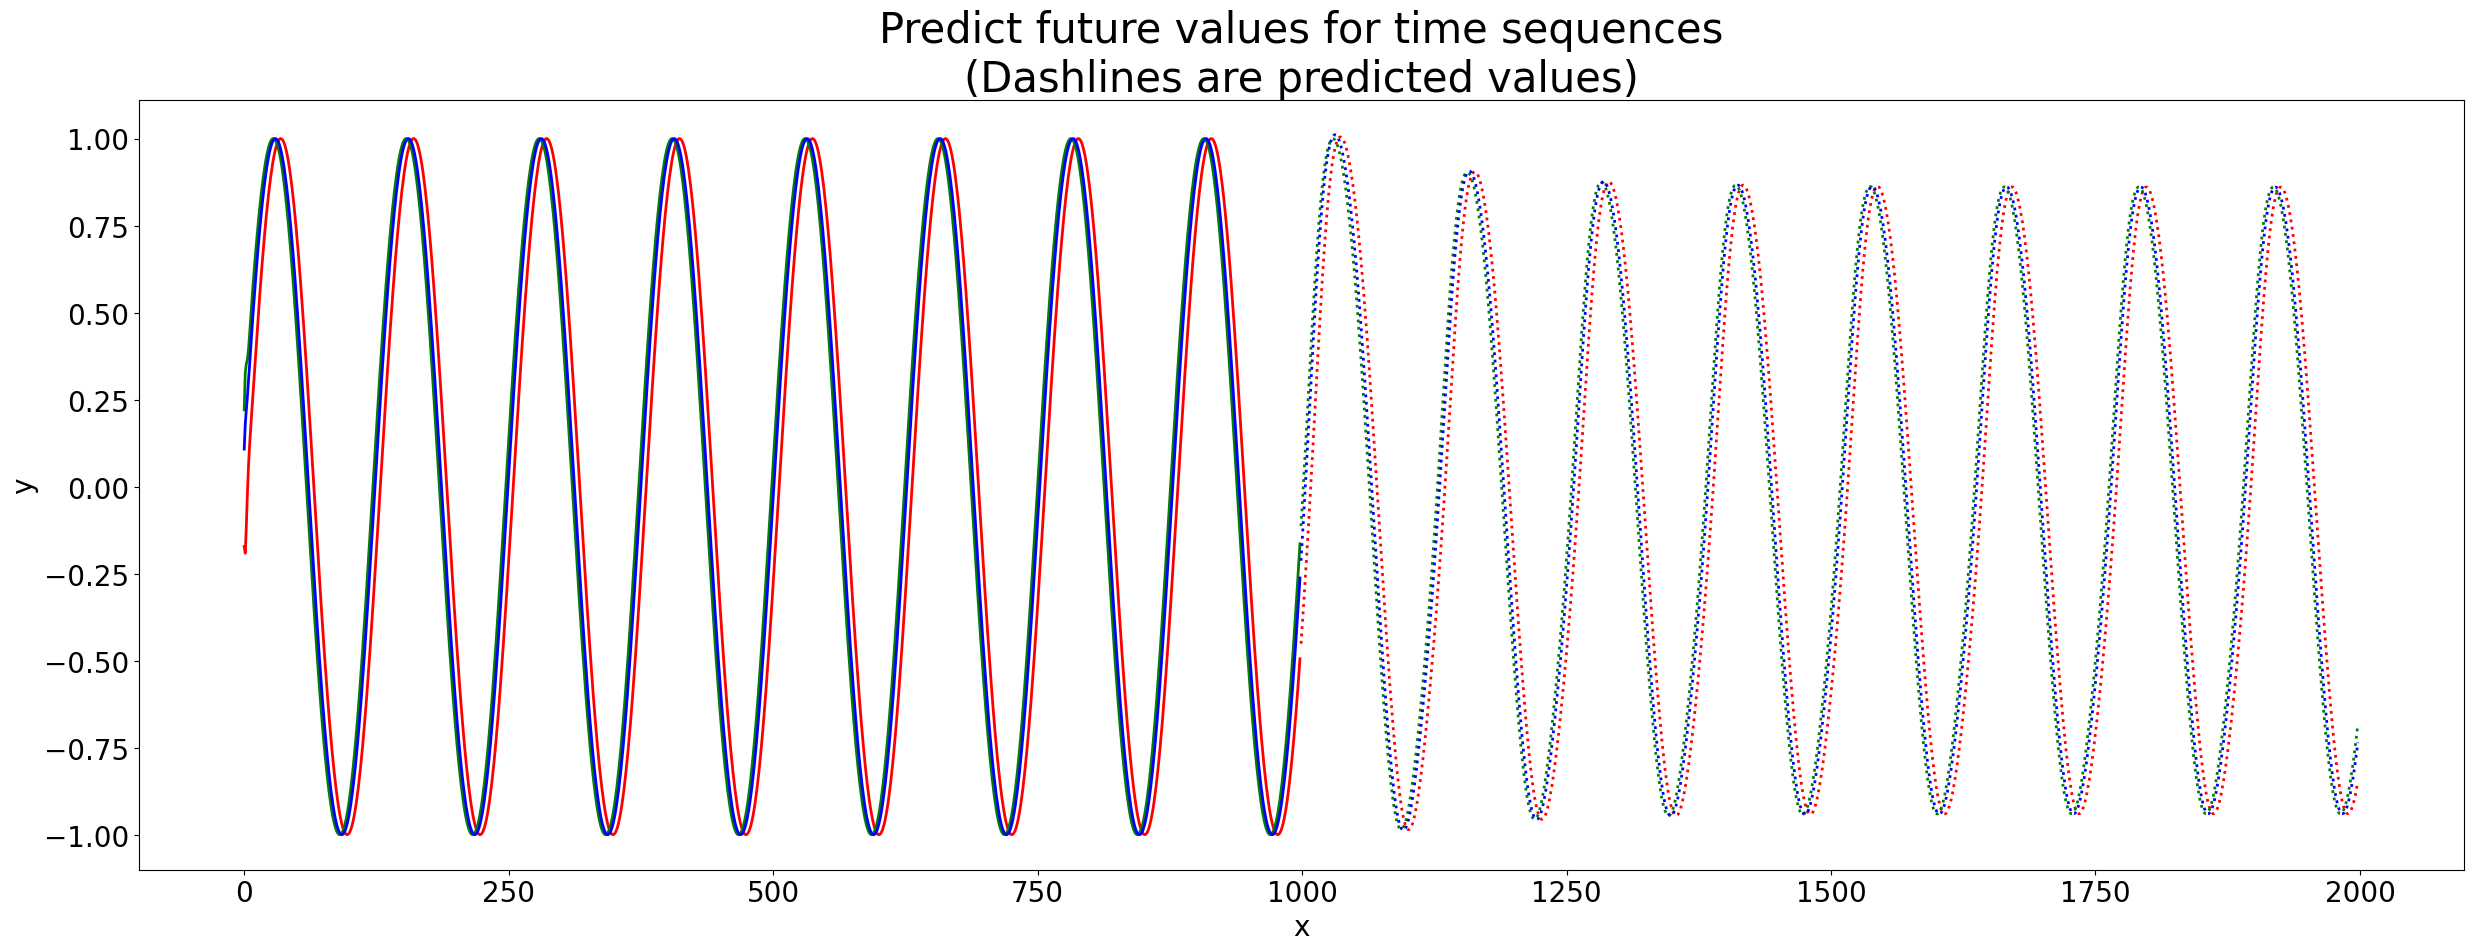

In [6]:
#Show the last result here:
input = torch.from_numpy(data[3:, :-1])
plt.figure(figsize=(30,10))
plt.title('Predict future values for time sequences\n(Dashlines are predicted values)', fontsize=30)
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
def draw(yi, color):
    plt.plot(np.arange(input.size(1)), yi[:input.size(1)], color, linewidth = 2.0)
    plt.plot(np.arange(input.size(1), input.size(1) + future), yi[input.size(1):], color + ':', linewidth = 2.0)
draw(y[0], 'r')
draw(y[1], 'g')
draw(y[2], 'b')
plt.show()

Run the following to download the files from Google Colab

In [7]:
from google.colab import files

fiiles_list = os.listdir()
for f in fiiles_list:
  if ".pdf" in f:
    files.download(f)

ModuleNotFoundError: No module named 'google.colab'

## Problem 2: Variational AutoEncoder Image Generation

### Autoencoders
Autoencoders (AE) map a high-dimensional feature space to a compressed feature space (code $h$) then decompress to the output space of same dimension of the input space. The goal of compressing the feature space into the *code* is to make the representation of the key, essential information more compact. The component of the network that maps the high-dimensional input to the compressed *code* is termed the Encoder, and the component of the network that decompresses the code to a representative high-dimensional feature space is termed the Decoder.

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/37/Autoencoder_schema.png/440px-Autoencoder_schema.png" width="500"/>
</div>

Now it is understood that due to compression, some information will inevitably be lost, but the essential information required to construct the *essence* of the input is retained in the *code* ($h$).

<div>
<img src="https://processminer.com/wp-content/uploads/processminer-insights-autoencoder-in-keras-1.jpg" width="500"/>
</div>
<div>
<img src="https://www.jeremyjordan.me/content/images/2018/03/Screen-Shot-2018-03-07-at-8.24.37-AM.png" width="500"/>
</div>

A practical example of this is the *denoising* of images:

<div>
<img src="https://miro.medium.com/max/1400/1*sHOPK4Mm5kl5-fju9kLByg.png" width="500"/>
</div>
which often requires the use of Convolutional Nueral Networks (CNNs)

[example](https://github.com/arthurmeyer/Saliency_Detection_Convolutional_Autoencoder)

<div>
<img src="https://www.researchgate.net/profile/Xifeng_Guo/publication/320658590/figure/fig1/AS:614154637418504@1523437284408/The-structure-of-proposed-Convolutional-AutoEncoders-CAE-for-MNIST-In-the-middle-there.png" width="500"/>
</div>

<div>
<img src="https://user-images.githubusercontent.com/26786663/27525317-b3026976-5a77-11e7-8767-8f4a06e5b696.jpg" width="500"/>
</div>


But to perform supervised training of the Autoencoder, we must first define the loss function, which will be often be the Mean Squared Error (MSE) loss between the input $x$ and the predicted output $\hat{x}$: 
$$\mathcal{L}_{MSE} = ||x-\hat{x}||^2$$

of course this loss will never be zero, but by minimizing this loss, the prediction $\hat{x}$ will retain the salient features of the input $x$.

<div>
<img src="https://miro.medium.com/max/600/1*nqzWupxC60iAH2dYrFT78Q.png" width="500"/>
</div>

### Variational Autoencoders
Variational Autoencoder (VAE) is an extension of the autoencoder that specifically accounts for the fact that *labeled* data might not have an injective (one-to-one) mapping, but may instead may be better represented by a *distribution* that is learned in the training data. That is to say, for a given input $x$ it is not always best to predict an output $\hat{x}$ that is simply close to the given input $x$, but it is also important that for the given input, the output also reflect the distribution of similar points near $x$ that was observed in the training data.

<div>
<img src="https://miro.medium.com/max/1400/1*r1R0cxCnErWgE0P4Q-hI0Q.jpeg" width="500"/>
</div>

The key concept of the VAE comes from the use of Gaussian Mixture Models (GMMs) to approximate some (multivariate) distribution $P(x)$. To achieve this, a set of Gaussians is required, and the goal is to at any point, select the appropriate Gaussian that best approximates the output of $P(x)$ at that point. 

**So in the autoencder we had a *code* $h$, but now, we replace this *code* in the VAE with a continuous variable $z$ which follows a standard normal distribution $N(0,1)$ (0 mean, standard deviation of 1).** So for each sample $z$ there is an associated mean and standard deviation variables $\mu$ and $\sigma$ of the Gaussian distribution corresponding to $z$. Just as in the GMM, if we integrate over all of the Gaussian distributions, the integrated domain becomes the original distribution $P(x)$: 
$$P(x) = \int_z P(z) P(x|z) $$

Where we have that $z \sim N(0,1)$ ($z$ is sample from normal distribution with 0 mean and variance of 1), $x|z \sim N(\mu(z),\sigma(z))$ (estimated variable $x$ is conditioned on the latent variable $z$ is sampled from a Gaussian distribution whose mean and variance are related to the continuous latent variable $z$). At this point, $P(z)$ is known to be ($N(0,1)$), and the conditional probability is what must be solved for as we need to find what $\mu,\sigma$ should be to help us approximate $P(x)$. 

Our goal is to produce results that are very similar to the input $x$, which means our objective is to maximize our prediction $P(x)$ (likelihood that we predict a value very similar to the input). If this is achieved on training points, then it is likely to produce silmiar samples when deployed.

So to maximize the $P(x)$, we can state this objective as $L$: 
$$max L = \sum_x log(P(x))$$
Here we leverage the log of the likelihood ($P(x)$) to give us a nice monotonically increasing function related to probability ($P(x) \in [0,1]$, therefore $log(P(x)) \in [-\infty,0] $ where when maximized $log(P(x)) = log(1) = 0$). 

Given the objective to maximize $log(P(x))$, we can first expand this term as follows: 

We introduce the distribution $q(z|x)$ which once summed over $z$ produces $\log P(x)$:
$$\log P(x) = \int_z q(z|x) \log (P(x)) dz$$

We then use [Bayes Theorem](https://en.wikipedia.org/wiki/Bayes%27_theorem) for dependent variables to make the substition in the $\log(\cdot)$ argument: 
$$ = \int_z q(z|x) \log \left(\frac{P(z,x)}{P(z|x)}\right) dz$$

We then multiply the $\log(\cdot)$ argument by 1, introducing to the numerator and denominator the distribution $q(z|x)$:
$$ = \int_z q(z|x) \log \left(\frac{P(z,x)q(z|x)}{q(z|x)P(z|x)}\right) dz$$

By [logarithmic identities](https://en.wikipedia.org/wiki/List_of_logarithmic_identities) we can turn this into two integrals separating terms as follows:
$$ = \int_z q(z|x) \log \left(\frac{P(z,x)}{q(z|x)}\right) dz + \int_z q(z|x) \log \left(\frac{q(z|x)}{P(z|x)}\right) dz$$

The second term is the [Kullback–Leibler (KL) divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) which has a value greater than or equal to zero:
$$ = \int_z q(z|x) \log \left(\frac{P(z,x)}{q(z|x)}\right) dz + D_{KL}(q(z|x)||P(z|x))$$
The KL divergence (also called relative entropy) is a statistical distance of how different two probability distributions are from each other, but the ordering matters for this metric. For $D_{KL}(Q||P)$ (the divergence of Q from P) is the expected excess *surprise* from using P as a model when the actual distribution is Q.
<div>
<img src="https://goodboychan.github.io/images/copied_from_nb/image/kl_qp.gif" width="500"/>
</div>
[another great animation of KL divergence](https://twitter.com/ari_seff/status/1303741288911638530)


**Because the KL term is equal to or greater than 0, we've found a lower bound of the $\log P(x)$** (again also leveraging Bayes theorem): 
$$ \log P(x) \geq \int_z q(z|x) \log \left(\frac{P(x|z)P(z)}{q(z|x)}\right) dz$$

We call this the Evidence Based Lower Bound (ELBO): 
$$ \log P(x) \geq ELBO =  \int_z q(z|x) \log \left(\frac{P(x|z)P(z)}{q(z|x)}\right) dz = E_{q(z|x)} \left[ \log \frac{p(x,z)}{q(z|x)} \right]$$
The last term on the right above leverages [Expected value](https://en.wikipedia.org/wiki/Expected_value) notation $E[\cdot]$.

So we can rewrite the original form as follows: 

$$\log P(x) = ELBO + D_{KL}(q(z|x) || P(z|x))$$

<div>
<img src="https://miro.medium.com/max/1400/1*adWF4RN7v_PqXPV984hjSw.png" width="500"/>
</div>

By adjusting $q(z|x)$ to make the ELBO higher, the KL divergence must get smaller and smaller. We continue to update $q(z|x)$ until it is the same as $P(z|x)$ making the KL divergence converge to 0, and the ELBO and $\log P(x)$ are fully consistent. Maximizing $\log P(x)$ is equivalent to maximizing the ELBO.

Adjusting $P(x|z)$ is achieved by adjusting the Decoder, and adjusting $q(z|x)$ is adjusting the encoder. So everytime the decoder is updated, the encoder must be adjusted to be consistent with it so that the decoder will be continue to improve after each next training epoch.

We can further simplify our ELBO expression with the following derivation: 
$$ELBO =  \int_z q(z|x) \log \left(\frac{P(x|z)P(z)}{q(z|x)}\right) dz $$
by logarithmic identities ($\log(ab)= \log(a)+\log(b)$ where here $a = \frac{P(z)}{q(z|x)}$, $b = P(x|z)$: 
$$ ELBO =  \int_z q(z|x) \log \left(\frac{P(z)}{q(z|x)}\right) dz + \int_z q(z|x) \log \left(P(x|z)\right) dz $$

This can be rewritten using [KL divergence identity](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence)
$$ ELBO = -D_{KL}(q(z|x) || P(z)) + \int_z q(z|x) \log \left(P(x|z)\right) dz $$

Therefore, maximizing the ELBO is equivalent to minimize $D_{KL}(q(z|x)||P(z))$ (as it is a negative value) and maximizing the integral equation in the second term of the above:
$$max  \int_z q(z|x) \log \left(P(x|z)\right) dz = max E_{q(z|x)}[\log P(x|z)] $$

The above expectation $ max E_{q(z|x)}[\log P(x|z)]$ means maximize the likelihood $P(x|z)$ (Decoder’s output) given that $q(z|x)$ (Encoder’s output) is as high as possible. This is similar to AutoEncoder’s loss function (reconstruction error):

$$ L = (x-\hat{x})^2 $$

Finally, we can simplify $-D_{KL}(q(z|x)||P(z))$ by first decomposing its components using the logarithimc properties $\log(\frac{a}{b}) = \log(a)-\log(b)$ where $a=P(z)$ and $b= q(z|x)$, so for $P(z)$: 
$$\int_z q(z|x) \log P(z) dz = \int_z N(z; \mu, \sigma^2) \log N(z; 0,I)dz$$
which for the special case of our distributions being Gaussian, is equivalent to 
$$= -\frac{J}{2} \log(2\pi) - \frac{1}{2} \sum_{i=1}^J (\mu_i^2 + \sigma_i^2)$$

where $J$ is the dimensionality of $z$, $\mu,\sigma$ denote the variational mean and standard deviation vectors, and $\mu_i,\sigma_i$ simply denote the i-th element of these vectors.

Likewise, for $q(z|x)$: 
$$\int_z q(z|x) \log q(z|x) dz = \int_z N(z; \mu, \sigma^2) \log N(z; \mu,\sigma^2)dz$$
which for the Gaussian case is equivalent to the closed form: 
$$= -\frac{J}{2} \log(2\pi) - \frac{1}{2} \sum_{i=1}^J (1 + \log \sigma_i^2)$$

Therefore we can write $-KL(q(z|x)||P(z))$ as:

$$-D_{KL}(q(z|x)||P(z)) = \int_z q(z|x) \left( \log P(z) - \log q(z|x) \right)dz $$
which in closed form is:
$$-D_{KL}(q(z|x)||P(z)) = -\frac{1}{2} \sum_{i=1}^J (1+\log(\sigma_i^2) - \mu_i^2 - \sigma_i^2) $$
where again, $\mu_i,\sigma_i$ simply denote the i-th element of these vectors $\mu,\sigma$.

If we use a Bernoulli or Gaussian Multi-Layer Perception (MLP) to capture the distributions $q(z|x) = q_{\phi}(z|x)$, $P(z) = p_{\theta}(z)$, $P(x|z) = p_{\theta}(x|z)$, then for a marginal likelihood composed of a sum over the marginal likelihoods of individual datapoints $\log p_{\theta}(x^{(1)},\ldots,x^{(N)}) = \sum_{i=1}^N \log p_{\theta}(x^{(i)})$ then this marginal likelihood we've seen for the i-th datapoint is: 
$$\log p_{\theta}(x^{(i)}) = \underbrace{D_{KL}(q_{\phi}(z|x^{(i)}) || p_{\theta}(z|x^{(i)}) )}_{\text{regularization}}+ \underbrace{\mathcal{L}(\theta,\phi; x^{(i)})}_{\text{loss}}$$

Then the loss term is: 
$${L}(\theta,\phi; x^{(i)}) = \underbrace{-D_{KL}(q_{\phi}(z|x^{(i)})|| p_{\theta}(z))}_{\text{regularization}} + \underbrace{\mathbb{E}_{q_{\phi}(z|x^{(i)})} \left[ log p_{\theta}(x^{(i)}|z) \right]}_{\text{reconstruction }}$$

Which simplified becomes: 
$${L}(\theta,\phi; x^{(i)}) \simeq \frac{1}{2} \sum_{j=1}^J \left( 1 + \log((\sigma_j^{(i)})^2) - (\mu_{j}^{(i)})^2 - (\sigma_{j}^{(i)})^2  \right) + \frac{1}{L} \sum_{l=1}^L \log p_{\theta}(x^{(i)}|z^{(i,l)}) $$
where from the *reparameterization trick* we have $z^{(i,l)} =\mu^{(i)} + \underbrace{\sigma^{(i)} \odot \epsilon^{(l)}}_{\text{element-wise product}} $ and $\epsilon^{(l)} \sim \mathcal{N}(0,I)$


Good References: 
- [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- [Variatinoal Autoencoder (VAE) - Roger](https://medium.com/geekculture/variational-autoencoder-vae-9b8ce5475f68)
- [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908)
### Your Problem: MINST Dataset
(note: this problem requires internet access to download the dataset)

In this problem you will leverage a VAE to perform image reconstruction for a hand-written number given an input. Your output will be in distribution of the original input (an auto-generated 'hand-written' number of the same type)

<div>
<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/MnistExamples.png" width="500"/>
</div>

### Your Code:
(see spots indicated "fill this in")

In [2]:
def student_function_2(train_loader,test_loader,batch_size = 128, epochs = 10,log_interval = 10, device="cpu"):
    """
    Description: This is an implementation of a VAE for written text generation. Given an input number, this 
    network is capable of producing another written number that looks very similar to the distribution of the 
    number it was shown. 
    
    
    
    Parameters
    ----------
    train_loader : torch.utils.data.DataLoader
        object for loading training data
    test_loader : torch.utils.data.DataLoader
        Object for loading test data
    cuda_bool : bool
        boolean if GPU (cuda) is available
    batch_size : int
        size of each batch for a given epoch
    epochs : int
        number of epochs for training
    log_interval : int 
        This is a counter to display training progress
        
    device : string
        does this machine have GPU (cuda) or just CPU? (default is CPU, but script in eval below checks for gpu and uses that if available)
    Returns
    -------
    implement_bool : bool
        true/false - has the function been implemented?
    """
    # raise NotImplementedError #comment/delete this once implemented

    class VAE(nn.Module):
        def __init__(self):
            super(VAE, self).__init__()
            #Define the architecture
            self.fc1 = nn.Linear(784, 400)
            self.fc21 = nn.Linear(400, 20)
            self.fc22 = nn.Linear(400, 20)
            self.fc3 = nn.Linear(20, 400)
            self.fc4 = nn.Linear(400, 784)

        def encode(self, x):
            h1 = F.relu(self.fc1(x))
            return self.fc21(h1), self.fc22(h1)

        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5*logvar)
            eps = torch.randn_like(std)
            return mu + eps*std

        def decode(self, z):
            h3 = F.relu(self.fc3(z))
            return torch.sigmoid(self.fc4(h3))

        def forward(self, x):
            mu, logvar = self.encode(x.view(-1, 784))
            z = self.reparameterize(mu, logvar)
            return self.decode(z), mu, logvar


    model = VAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)


    # Reconstruction + KL divergence losses summed over all elements and batch
    def loss_function(recon_x, x, mu, logvar):
        # Reconstruction loss (classified correctly in this problem, could be regression in others): 
        # Binary cross entropy:
        BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

        # see Appendix B from VAE paper:
        # Kingma and Welling. Auto-Encoding Variational Bayes. ICLR, 2014
        # https://arxiv.org/abs/1312.6114
        # KLD = -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        #Hint: use torch.sum(...) for summation; mu.pow(2) for mu^2; logvar.exp() for sigma^2
        
        #FILL THIS IN
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) 

        return BCE + KLD


    def train(epoch):
        model.train()
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            #Zero the optimizer gradients (for this epoch)
            optimizer.zero_grad()
            #get model output from input
            recon_batch, mu, logvar = model(data)
            #Get the loss:
            loss = loss_function(recon_batch, data, mu, logvar) #Make sure this is implemented above!
            #Perform backpropogation to adjust weights for better prediction
            loss.backward()
            train_loss += loss.item()
            #update the model:
            optimizer.step()
            if batch_idx % log_interval == 0:
                print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                    epoch, batch_idx * len(data), len(train_loader.dataset),
                    100. * batch_idx / len(train_loader),
                    loss.item() / len(data)))

        print('====> Epoch: {} Average loss: {:.4f}'.format(
              epoch, train_loss / len(train_loader.dataset)))

    def test(epoch):
        model.eval() #put model in evaluation mode
        test_loss = 0
        with torch.no_grad():
            for i, (data, _) in enumerate(test_loader):
                data = data.to(device) #Use the device you have (cpu vs gpu)
                recon_batch, mu, logvar = model(data) #evaluate the model
                test_loss += loss_function(recon_batch, data, mu, logvar).item() #get the test loss 
                #save images from performance:
                if i == 0:
                    n = min(data.size(0), 8)
                    comparison = torch.cat([data[:n],
                                          recon_batch.view(batch_size, 1, 28, 28)[:n]])
                    save_image(comparison.cpu(),
                             'results/reconstruction_' + str(epoch) + '.png', nrow=n)

        test_loss /= len(test_loader.dataset)
        print('====> Test set loss: {:.4f}'.format(test_loss))

    #Here is where things start in this script:
    for epoch in range(1, epochs + 1):
        train(epoch) #train for the epoch
        test(epoch) #test for epoch

        with torch.no_grad():
            #display current results
            sample = torch.randn(64, 20).to(device)
            sample = model.decode(sample).cpu()
            save_image(sample.view(64, 1, 28, 28),
                       'results/sample_' + str(epoch) + '.png') #this samples the latent space 64 times per epoch, generating images that are 28x28pix


    implement_bool = True #has script been implemented?
    return implement_bool
    

### Evaluation

In [5]:
#Setup Necessary variables"

#make a 'results' folder for putting results:
MYDIR = ("results")
CHECK_FOLDER = os.path.isdir(MYDIR)
if not CHECK_FOLDER: os.makedirs(MYDIR) # If folder doesn't exist, then create it.

#Set Arguments
cuda_bool = torch.cuda.is_available() #Determine if GPU is available (cuda)
batch_size = 128 #size of batches (how many imgs to train together)
epochs = 10 #iterations of convergence
log_interval = 10 #count for printing training progress
seed = 1 #value for seed values for network weights 
torch.manual_seed(seed) #seed value for network weights
#use GPU if available:
device = torch.device("cuda" if cuda_bool else "cpu")

#Load data:
kwargs = {'num_workers': 1, 'pin_memory': True} if cuda_bool else {}
train_loader = torch.utils.data.DataLoader(
    datasets.MNIST(data_path, train=True, download=True,
                   transform=transforms.ToTensor()),
    batch_size= batch_size, shuffle=True, **kwargs)
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST(data_path, train=False, transform=transforms.ToTensor()),
    batch_size= batch_size, shuffle=True, **kwargs)

#Your code:
complete_bool = student_function_2(train_loader,test_loader,device=device)


Train Epoch: 1 [0/60000 (0%)]	Loss: 550.513916
Train Epoch: 1 [1280/60000 (2%)]	Loss: 310.610535
Train Epoch: 1 [2560/60000 (4%)]	Loss: 240.650436
Train Epoch: 1 [3840/60000 (6%)]	Loss: 219.223083
Train Epoch: 1 [5120/60000 (9%)]	Loss: 215.092896
Train Epoch: 1 [6400/60000 (11%)]	Loss: 208.449524
Train Epoch: 1 [7680/60000 (13%)]	Loss: 203.374680
Train Epoch: 1 [8960/60000 (15%)]	Loss: 193.757126
Train Epoch: 1 [10240/60000 (17%)]	Loss: 194.697510
Train Epoch: 1 [11520/60000 (19%)]	Loss: 192.934937
Train Epoch: 1 [12800/60000 (21%)]	Loss: 179.947601
Train Epoch: 1 [14080/60000 (23%)]	Loss: 174.070770
Train Epoch: 1 [15360/60000 (26%)]	Loss: 182.592896
Train Epoch: 1 [16640/60000 (28%)]	Loss: 168.164948
Train Epoch: 1 [17920/60000 (30%)]	Loss: 166.453857
Train Epoch: 1 [19200/60000 (32%)]	Loss: 161.456146
Train Epoch: 1 [20480/60000 (34%)]	Loss: 162.513474
Train Epoch: 1 [21760/60000 (36%)]	Loss: 151.486923
Train Epoch: 1 [23040/60000 (38%)]	Loss: 157.244186
Train Epoch: 1 [24320/60000 

### Run the following cells to display the results for grading:

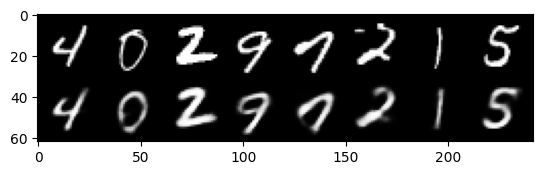

In [6]:
img = mpimg.imread('results/reconstruction_5.png')
plt.imshow(img)
plt.show()

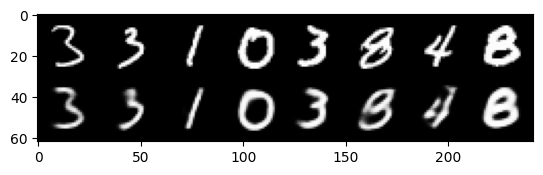

In [7]:
img = mpimg.imread('results/reconstruction_10.png')
plt.imshow(img)
plt.show()

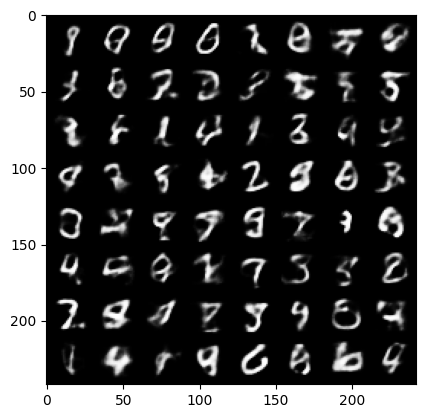

In [8]:
img = mpimg.imread('results/sample_10.png')
plt.imshow(img)
plt.show()

Run the following to download the files from Google Colab

In [ ]:
from google.colab import files
!zip -r /content/results.zip /content/results
files.download("/content/results.zip")

## Problem 3: Self-Attention for Sequence Prediction

### From Sequential to Parallel
In Problem 1, we used an LSTM to process sequences *step by step*, maintaining a hidden state that serves as memory. While effective, this sequential processing has a fundamental limitation: information from early timesteps must pass through many intermediate steps to influence later predictions, which can lead to information loss (the vanishing gradient problem).

**Attention** offers an alternative paradigm: instead of processing sequentially, we *look at all timesteps at once* and learn which ones are most important for making each prediction. This is the core idea behind the ["Attention Is All You Need"](https://arxiv.org/abs/1706.03762) paper (Vaswani et al., 2017), which introduced the Transformer architecture that powers modern language models (GPT, BERT, etc.). Since then, transformers are a staple in the fields of robotics, NLP, computer vision, sound processing etc. It doesn't lose "memory" like LSTMs, but scales so elegantly, and has formed the foundation of "scaling laws".

### Scaled Dot-Product Attention

The attention mechanism uses three components: **Queries** ($Q$), **Keys** ($K$), and **Values** ($V$). An intuitive analogy is a library search:
- **Query**: what you are looking for (your search terms)
- **Key**: the label/index on each book (what each item offers)
- **Value**: the actual content of each book (the information you retrieve)

The attention mechanism computes a weighted sum of Values, where the weight for each Value is determined by how well the corresponding Key matches the Query:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

where $d_k$ is the dimension of the key vectors. The scaling factor $\frac{1}{\sqrt{d_k}}$ is critical: without it, the dot products $QK^T$ grow large in magnitude as $d_k$ increases, pushing the softmax function into regions where it has extremely small gradients, effectively preventing learning.

<div>
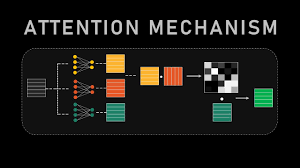
</div>

### Multi-Head Attention
Rather than performing a single attention function, *multi-head attention* runs the attention mechanism multiple times in parallel with different learned linear projections of $Q$, $K$, and $V$. Each "head" can learn to attend to different types of relationships in the data (e.g., one head might focus on nearby timesteps while another captures long-range periodicity). The outputs of all heads are concatenated and linearly projected to produce the final result.



### References
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762)
- [The Illustrated Transformer (Jay Alammar)](https://jalammar.github.io/illustrated-transformer/)
- [PyTorch MultiheadAttention documentation](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html)

### Your Problem: Attention-Based Sequence Prediction

In this problem, you will build a **self-attention model** to predict the **same sine wave sequences from Problem 1**. This allows a direct comparison between the LSTM approach (sequential memory) and the attention approach (parallel, weighted lookups, arguably simpler!).

Your model architecture:
$$x \rightarrow \text{Linear}(1, d_\text{model}) \rightarrow \text{Self-Attention}(Q,K,V) \rightarrow \text{Linear}(d_\text{model}, 1) \rightarrow y$$

You will implement:
1. The $Q$, $K$, $V$ projection layers
2. The `scaled_dot_product_attention` function (compute scores, apply softmax, weighted sum)
3. The forward pass wiring these components together

After training, you will visualize the **attention weight heatmap** to see which input timesteps the model "attends to" when making each prediction.

### Your Code:

In [9]:
def student_function_3(data, lr=0.001, training_steps=75, seq_len=50, pred_len=10, d_model=64):
    """
    Description: This function implements a self-attention model for sequence prediction.
    Uses the same sine wave data as Problem 1, but instead of sequential LSTM processing,
    the model uses scaled dot-product attention to look at all timesteps at once.
    
    Parameters
    ----------
    data : np.ndarray
        input data (sine wave sequences), shape (N, L)
    lr : float
        learning rate for Adam optimizer
    training_steps : int
        number of training epochs -- you can reduce this number for faster training!
    seq_len : int
        number of input timesteps to use as context
    pred_len : int
        number of future timesteps to predict
    d_model : int
        dimension of the model's internal representations
        
    Returns
    -------
    predictions : np.ndarray
        predicted sequences
    attn_weights : np.ndarray
        attention weights for visualization (shape: seq_len x seq_len)
    """
    # raise NotImplementedError  # comment this out once implemented

    def scaled_dot_product_attention(Q, K, V):
        """
        Compute scaled dot-product attention.
        
        Recall the formula from the problem description:
            Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
        
        Args:
            Q: Queries, shape (batch, seq_len, d_k)
            K: Keys, shape (batch, seq_len, d_k)
            V: Values, shape (batch, seq_len, d_k)
            
        Returns:
            output: weighted sum of values, shape (batch, seq_len, d_k)
            attn_weights: attention weights, shape (batch, seq_len, seq_len)
        """
        d_k = Q.size(-1)

        # Step 1: Compute raw attention scores.
        # You need to multiply Q by K^T and scale by sqrt(d_k).
        # Remember these are batched tensors — use the appropriate
        # batched matrix multiplication from PyTorch.
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

        # Step 2: Convert scores to a probability distribution (attention weights).
        # Which dimension should you normalize over, and why?
        attn_weights = F.softmax(scores, dim=-1)

        # Step 3: Use the attention weights to compute a weighted combination of V.
        output = torch.matmul(attn_weights, V)

        return output, attn_weights

    class AttentionSeqModel(nn.Module):
        def __init__(self, d_model=64):
            super(AttentionSeqModel, self).__init__()
            self.d_model = d_model

            # Project scalar input to d_model dimensions (provided)
            self.input_proj = nn.Linear(1, d_model)

            # Define the Q, K, V projection layers.
            # Each should map from d_model dimensions to d_model dimensions.
            self.W_Q = nn.Linear(d_model, d_model)
            self.W_K = nn.Linear(d_model, d_model)
            self.W_V = nn.Linear(d_model, d_model)

            # Output projection (provided): maps from d_model back to scalar
            self.output_proj = nn.Linear(d_model, 1)

        def forward(self, x):
            """
            Forward pass of the attention model.
            
            Args:
                x: input sequence, shape (batch, seq_len, 1)
            Returns:
                output: predicted values, shape (batch, seq_len, 1)
                attn_weights: attention weight matrix, shape (batch, seq_len, seq_len)
            """  
            # Project input to d_model dimensions (provided)
            x_proj = self.input_proj(x)  # (batch, seq_len, d_model)

            # Produce Q, K, V from the projected input using the layers above.
            # In self-attention, Q, K, and V all come from the same source
            # but are transformed through different learned projections.
            Q = self.W_Q(x_proj)
            K = self.W_K(x_proj)
            V = self.W_V(x_proj)

            # Apply scaled dot-product attention (provided call)
            attn_output, attn_weights = scaled_dot_product_attention(Q, K, V)

            # Project back to scalar output (provided)
            output = self.output_proj(attn_output)  # (batch, seq_len, 1)

            return output, attn_weights

    # ---- Data Preparation (provided) ----
    # Create input-target pairs from the sine wave data
    # Input: seq_len timesteps, Target: the next pred_len timesteps shifted by 1
    N, L = data.shape
    inputs = []
    targets = []
    for i in range(N):
        for j in range(0, L - seq_len - pred_len, pred_len):
            inputs.append(data[i, j:j+seq_len])
            targets.append(data[i, j+1:j+seq_len+1])  # shifted by 1
    
    inputs = torch.FloatTensor(np.array(inputs)).unsqueeze(-1)   # (num_samples, seq_len, 1)
    targets = torch.FloatTensor(np.array(targets)).unsqueeze(-1)  # (num_samples, seq_len, 1)

    # ---- Training (provided) ----
    model = AttentionSeqModel(d_model=d_model)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    model.train()
    for epoch in range(training_steps):
        optimizer.zero_grad()
        pred, attn_w = model(inputs)
        loss = criterion(pred, targets)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 50 == 0:
            print(f'Epoch {epoch+1}/{training_steps}, Loss: {loss.item():.6f}')

    # ---- Extract predictions and attention weights (provided) ----
    model.eval()
    with torch.no_grad():
        # Use the first 3 sequences for visualization (like Problem 1)
        test_inputs = []
        for i in range(3):
            test_inputs.append(data[i, :seq_len])
        test_tensor = torch.FloatTensor(np.array(test_inputs)).unsqueeze(-1)
        predictions, attn_weights = model(test_tensor)

    return predictions.squeeze(-1).numpy(), attn_weights[0].numpy()

### Evaluation

In [10]:
# Generate sine wave data (same as Problem 1)
np.random.seed(2)
T = 20
L = 1000
N = 100

x = np.empty((N, L), 'int64')
x[:] = np.array(range(L)) + np.random.randint(-4, 4, N).reshape(N, 1)
data = np.sin(x / 1.0 / T).astype('float64')

# Call your attention model
predictions_3, attn_weights_3 = student_function_3(data)

Epoch 50/75, Loss: 0.053542


### Visualize Attention Weights

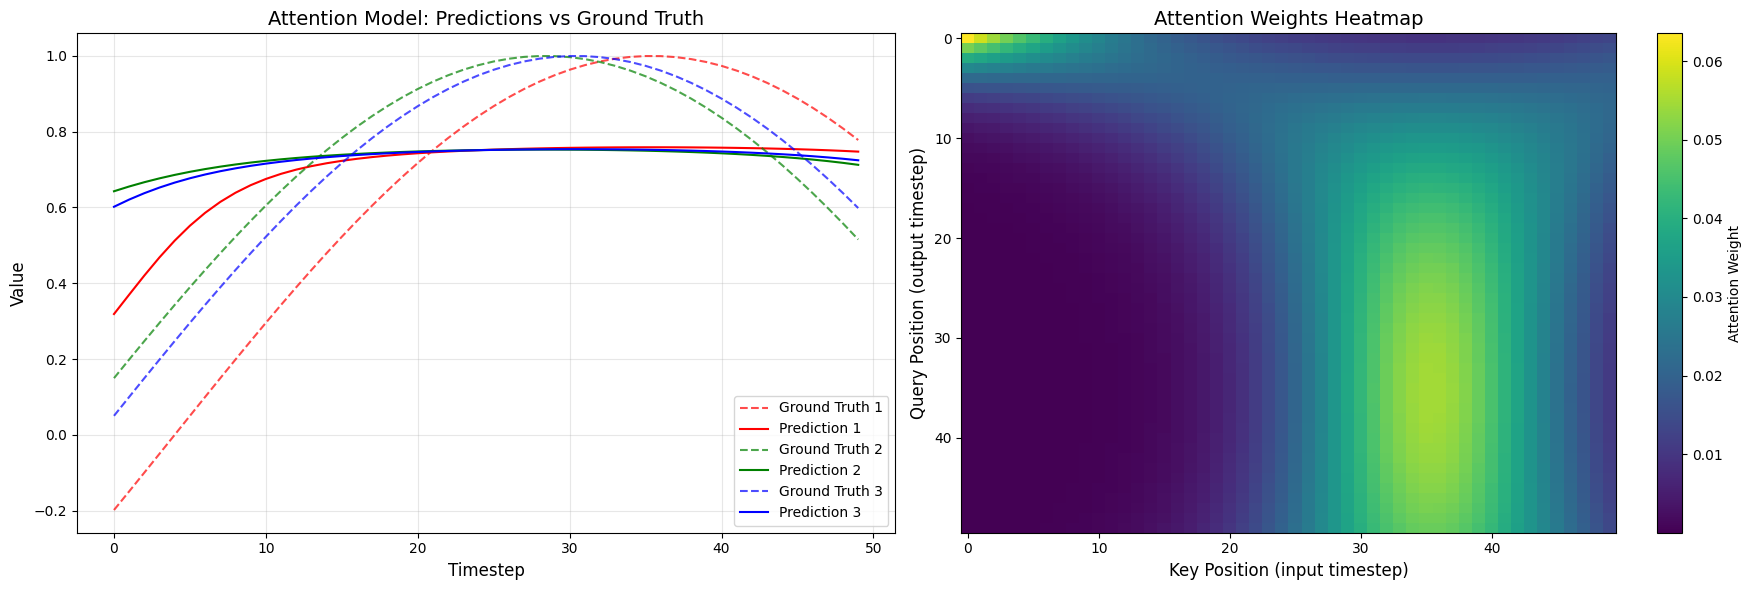

Attention weights shape: (50, 50)
Notice how the attention pattern shows which input timesteps influence each output prediction.


In [11]:
# Plot 1: Predictions vs Ground Truth
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: predictions vs ground truth
seq_len = predictions_3.shape[1]
colors = ['r', 'g', 'b']
for i in range(3):
    ground_truth = data[i, :seq_len]
    axes[0].plot(ground_truth, colors[i] + '--', linewidth=1.5, label=f'Ground Truth {i+1}', alpha=0.7)
    axes[0].plot(predictions_3[i], colors[i], linewidth=1.5, label=f'Prediction {i+1}')
axes[0].set_title('Attention Model: Predictions vs Ground Truth', fontsize=14)
axes[0].set_xlabel('Timestep', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Attention weight heatmap
im = axes[1].imshow(attn_weights_3, cmap='viridis', aspect='auto')
axes[1].set_title('Attention Weights Heatmap', fontsize=14)
axes[1].set_xlabel('Key Position (input timestep)', fontsize=12)
axes[1].set_ylabel('Query Position (output timestep)', fontsize=12)
plt.colorbar(im, ax=axes[1], label='Attention Weight')

plt.tight_layout()
plt.savefig('attention_results.pdf')
plt.show()
print("Attention weights shape:", attn_weights_3.shape)
print("Notice how the attention pattern shows which input timesteps influence each output prediction.")

### Bonus Question: Attention Beyond Text Sequences

In this problem, we applied self-attention to **time-series data** (sine wave sequences). BUT, the attention mechanism is remarkably versatile and has been adopted across many different data modalities beyond text and simple 1D sequences.

**Your task:** Name **one concrete example** of how attention (or Transformers) has been applied to a **different data modality** relevant to robotics or mechanical engineering or computer science. Briefly describe (2-3 sentences):
1. What is the data modality? (e.g., force/torque signals, point clouds, multi-agent trajectories, etc.)
2. What role does attention play in that application? (e.g., what is it "attending to" and why is that useful?)

*Hint: Think about the types of sequential or structured data a robot encounters —- contact force profiles during manipulation, 3D point clouds from depth sensors

I looked online and it seems that, in legged locomotion, transformers have beeen used for terrain aware quadruped control, where the input tokens are local terrain patches (as an example, a height map or point cloud) plus positional states overtime (things like joint angles, or velocities). The model in this case treats each patch and each timestep as a token and uses self attention to relate them. As an example it could focus on the patches under its feet that are about to make contact, on upcoming obstacles, or on past contact events that would impact its balance. Self Attention seems useful in this case, because the useful infomation is spatially and temporally sparse, meaning only some past states are relevant for the current action, and in this case the transformer would learn to weight the tokens instead of treating all terain history equally, which would help the robot to walk in challenging terrains. 

## Problem 4: DINOv2 Vision Feature Exploration

### Vision Transformers (ViTs)
Vision Transformers apply the Transformer architecture (from Problem 3) to images. The key idea is to split an image into fixed-size **patches** — analogous to words in a sentence — and process them with self-attention. Each patch is linearly embedded into a vector, and these patch embeddings are processed by a standard Transformer encoder. For example, the tokens of the top of an image (clouds, sky), can affect the tokens at the bottom of an image (beach, ground, not higher sky) thanks to attention.

<div>
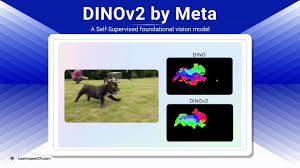
</div>

For example, with a **patch size of 14 pixels** and an input image of $518 \times 518$ pixels, we obtain a $37 \times 37 = 1369$ grid of patch tokens, plus one special `[CLS]` token that summarizes the entire image.

### DINOv2: Self-Supervised Visual Features
[DINOv2](https://arxiv.org/abs/2304.07193) (Oquab et al., 2023) is a self-supervised pretrained Vision Transformer from Meta AI Research. It is trained **without any labels** using a self-distillation objective: a student network learns to match the output of a teacher network (an exponential moving average of the student) on different augmented views of the same image. For example, a photo of a bear closer up is the same as a photo of the bear farther away, right? The features should be similar. 

The result is a model that produces **rich, semantically meaningful patch-level features** — patches depicting similar semantic content (e.g., two parts of a dog's fur, or two regions of sky) will have similar feature vectors, even without any supervised training. No labels -- it just works well!! And since there are smaller versions of this model, one might call it a "free gift".

### Cosine Similarity
Each patch token from DINOv2 is a feature vector (384 dimensions for ViT-S/14). We measure similarity using **cosine similarity**:

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}$$

which ranges from $-1$ (opposite) to $1$ (identical direction). Patches with high cosine similarity represent semantically similar regions.

### References
- [DINOv2: Learning Robust Visual Features without Supervision](https://arxiv.org/abs/2304.07193)
- [An Image is Worth 16x16 Words (ViT paper)](https://arxiv.org/abs/2010.11929)
- [PyTorch Hub: DINOv2](https://pytorch.org/hub/facebookresearch_dinov2_main/)

### Your Problem: Interactive Feature Visualization

In this problem, you will:
1. Load a pretrained DINOv2 model (`dinov2_vits14`) using `torch.hub`
2. Extract patch token features from a sample image
3. Compute cosine similarity between a reference patch and all other patches
4. Build an interactive matplotlib visualization where mousing over the image highlights semantically similar regions
5. Generate static similarity visualizations for several reference points (for PDF submission)

### Your Code:

In [12]:
def student_function_4(image_url):
    """
    Description: Loads a pretrained DINOv2 ViT-S/14 model, extracts patch token features
    from an image, and provides interactive + static cosine similarity visualization.
    
    Parameters
    ----------
    image_url : str
        URL of the image to analyze
        
    Returns
    -------
    explorer : DINOv2FeatureExplorer
        The explorer object with extracted features, for use in visualization
    """
    # raise NotImplementedError  # comment this out once implemented

    class DINOv2FeatureExplorer:
        def __init__(self):
            # Load pretrained DINOv2 ViT-S/14 model (provided)
            self.model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
            self.model.eval()
            self.patch_size = 14
            self.feat_dim = 384  # ViT-S/14 feature dimension

            # Image preprocessing transform (provided)
            self.transform = transforms.Compose([
                transforms.Resize(518),
                transforms.CenterCrop(518),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ])

            # These will be set after extract_features is called
            self.patch_tokens = None
            self.grid_h = None
            self.grid_w = None
            self.original_image = None

        def extract_features(self, image):
            """
            Extract patch token features from an image using DINOv2.
            
            Args:
                image: PIL Image
                
            Sets:
                self.patch_tokens: tensor of shape (num_patches, feat_dim)
                self.grid_h, self.grid_w: spatial dimensions of the patch grid
                self.original_image: the preprocessed image for display
            
            Useful references:
                - DINOv2 returns a dictionary from its forward pass. Explore the keys
                  to find the patch-level features (not the CLS token).
                - The model expects a 4D input tensor: (batch, channels, height, width).
                - After cropping to 518x518 with patch_size=14, think about how many
                  patches fit along each spatial dimension.
            """
            self.original_image = image.copy()

            # Step 1: Preprocess the image into a tensor suitable for the model.
            # The self.transform pipeline handles resize, crop, and normalization,
            # but the model expects a batch dimension.
            img_tensor = self.transform(image).unsqueeze(0)  # (1, 3, 518, 518)

            # Step 2: Pass the image through DINOv2 and extract patch token features.
            # DINOv2's forward pass returns a dictionary with several keys.
            # You need to find the correct key that contains the normalized patch tokens
            # (excluding the CLS token), and extract them as a 2D tensor of shape
            # (num_patches, feat_dim).
            # HINT: try printing features_dict.keys() to see what's available
            with torch.no_grad():
                features_dict = self.model.forward_features(img_tensor)
            
            self.patch_tokens = features_dict["x_norm_patchtokens"].squeeze(0)  # (num_patches, feat_dim)

            # Step 3: Compute the spatial grid dimensions.
            # Given the cropped image size (518x518) and self.patch_size, calculate
            # how many patches fit along the height and width.
            self.grid_h = 518 // self.patch_size  # 37
            self.grid_w = 518 // self.patch_size   # 37

        def compute_similarity(self, patch_idx):
            """
            Compute cosine similarity between the patch at patch_idx and all other patches.
            
            Args:
                patch_idx: integer index into the flattened patch token array
                
            Returns:
                similarity_map: numpy array of shape (grid_h, grid_w) with cosine similarities
            """
            # Get the reference patch token
            ref_token = self.patch_tokens[patch_idx]  # (feat_dim,)

            # Compute cosine similarity between ref_token and ALL patch tokens
            # HINT: use F.cosine_similarity(ref_token.unsqueeze(0), self.patch_tokens, dim=-1)
            similarities = F.cosine_similarity(ref_token.unsqueeze(0), self.patch_tokens, dim=-1).squeeze(0)

            # Reshape to spatial grid (provided)
            similarity_map = similarities.numpy().reshape(self.grid_h, self.grid_w)
            return similarity_map

        def pixel_to_patch(self, x, y):
            """
            Convert pixel coordinates to patch grid index.
            
            Args:
                x: pixel x-coordinate
                y: pixel y-coordinate
                
            Returns:
                patch_idx: linear index into the patch token array
            """
            # Convert pixel coords to patch grid coords
            patch_x = x // self.patch_size
            patch_y = y // self.patch_size

            # Clamp to valid range (provided)
            patch_x = min(patch_x, self.grid_w - 1)
            patch_y = min(patch_y, self.grid_h - 1)

            # Convert 2D grid position to linear index (provided)
            patch_idx = patch_y * self.grid_w + patch_x
            return patch_idx

    # ---- Setup (provided) ----
    # Download and load the image
    headers = {'User-Agent': 'ME326-HW4/1.0 (Stanford University; educational use)'}
    response = requests.get(image_url, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert('RGB')

    # Create explorer and extract features
    explorer = DINOv2FeatureExplorer()
    explorer.extract_features(image)

    return explorer

### Evaluation

In [13]:
# Sample image URL, of an interesting dinner table scene (no people)
image_url = "https://raw.githubusercontent.com/armlabstanford/collaborative-robotics-2026/main/dinner.jpg"

# Call your function
explorer = student_function_4(image_url)
print(f"Patch tokens shape: {explorer.patch_tokens.shape}")
print(f"Grid size: {explorer.grid_h} x {explorer.grid_w}")
print(f"Total patches: {explorer.grid_h * explorer.grid_w}")

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /home/frances/.cache/torch/hub/main.zip


/home/frances/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/frances/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/frances/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /home/frances/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 119MB/s]


Patch tokens shape: torch.Size([1369, 384])
Grid size: 37 x 37
Total patches: 1369


### Interactive Similarity Visualization
Run the cell below to launch an interactive visualization. **Mouse over the image** on the left to see a cosine similarity heatmap on the right, showing which other patches are most similar to the one under your cursor.

*(Note: interactive mode requires a matplotlib backend like `%matplotlib notebook` or `%matplotlib qt`. If running in Colab, use the static visualization below instead.)*

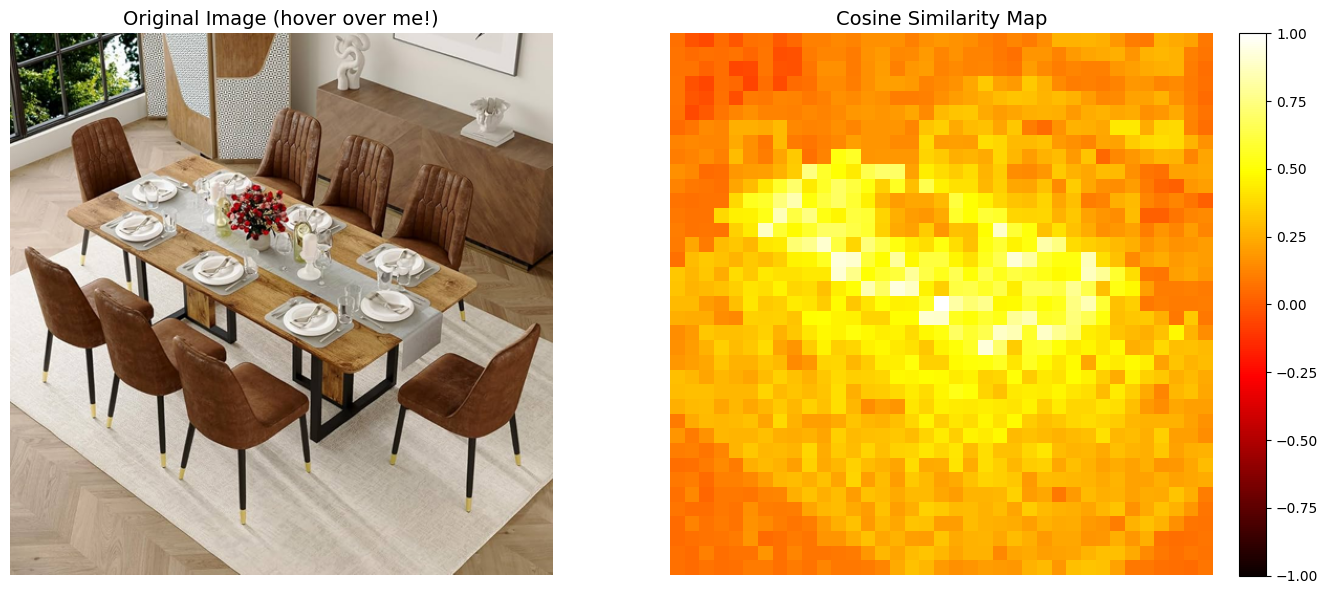

In [15]:
!pip install ipympl -q

def launch_interactive(explorer):
    """Launch interactive mouse-over similarity visualization."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Display original image on the left
    display_img = explorer.original_image.resize((518, 518))
    ax1.imshow(display_img)
    ax1.set_title('Original Image (hover over me!)', fontsize=14)
    ax1.axis('off')
    
    # Initialize similarity heatmap on the right
    # Start with center patch similarity
    center_idx = (explorer.grid_h // 2) * explorer.grid_w + (explorer.grid_w // 2)
    init_sim = explorer.compute_similarity(center_idx)
    heatmap = ax2.imshow(init_sim, cmap='hot', vmin=-1, vmax=1)
    ax2.set_title('Cosine Similarity Map', fontsize=14)
    ax2.axis('off')
    plt.colorbar(heatmap, ax=ax2, fraction=0.046, pad=0.04)
    
    # Reference point marker on the left image
    marker, = ax1.plot([], [], 'c+', markersize=20, markeredgewidth=3)
    
    def on_mouse_move(event):
        if event.inaxes == ax1 and event.xdata is not None and event.ydata is not None:
            x, y = int(event.xdata), int(event.ydata)
            if 0 <= x < 518 and 0 <= y < 518:
                patch_idx = explorer.pixel_to_patch(x, y)
                sim_map = explorer.compute_similarity(patch_idx)
                heatmap.set_data(sim_map)
                marker.set_data([x], [y])
                fig.canvas.draw_idle()
    
    fig.canvas.mpl_connect('motion_notify_event', on_mouse_move)
    plt.tight_layout()
    plt.show()

# Uncomment to run interactive mode:
launch_interactive(explorer)

### Static Similarity Visualization
The cell below generates static similarity maps for several reference points on the image. This is the key deliverable for your PDF submission, since interactive plots don't render in PDFs. We will check just to make sure the visualizations pass the sanity check!


/tmp/ipykernel_20133/1492887432.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


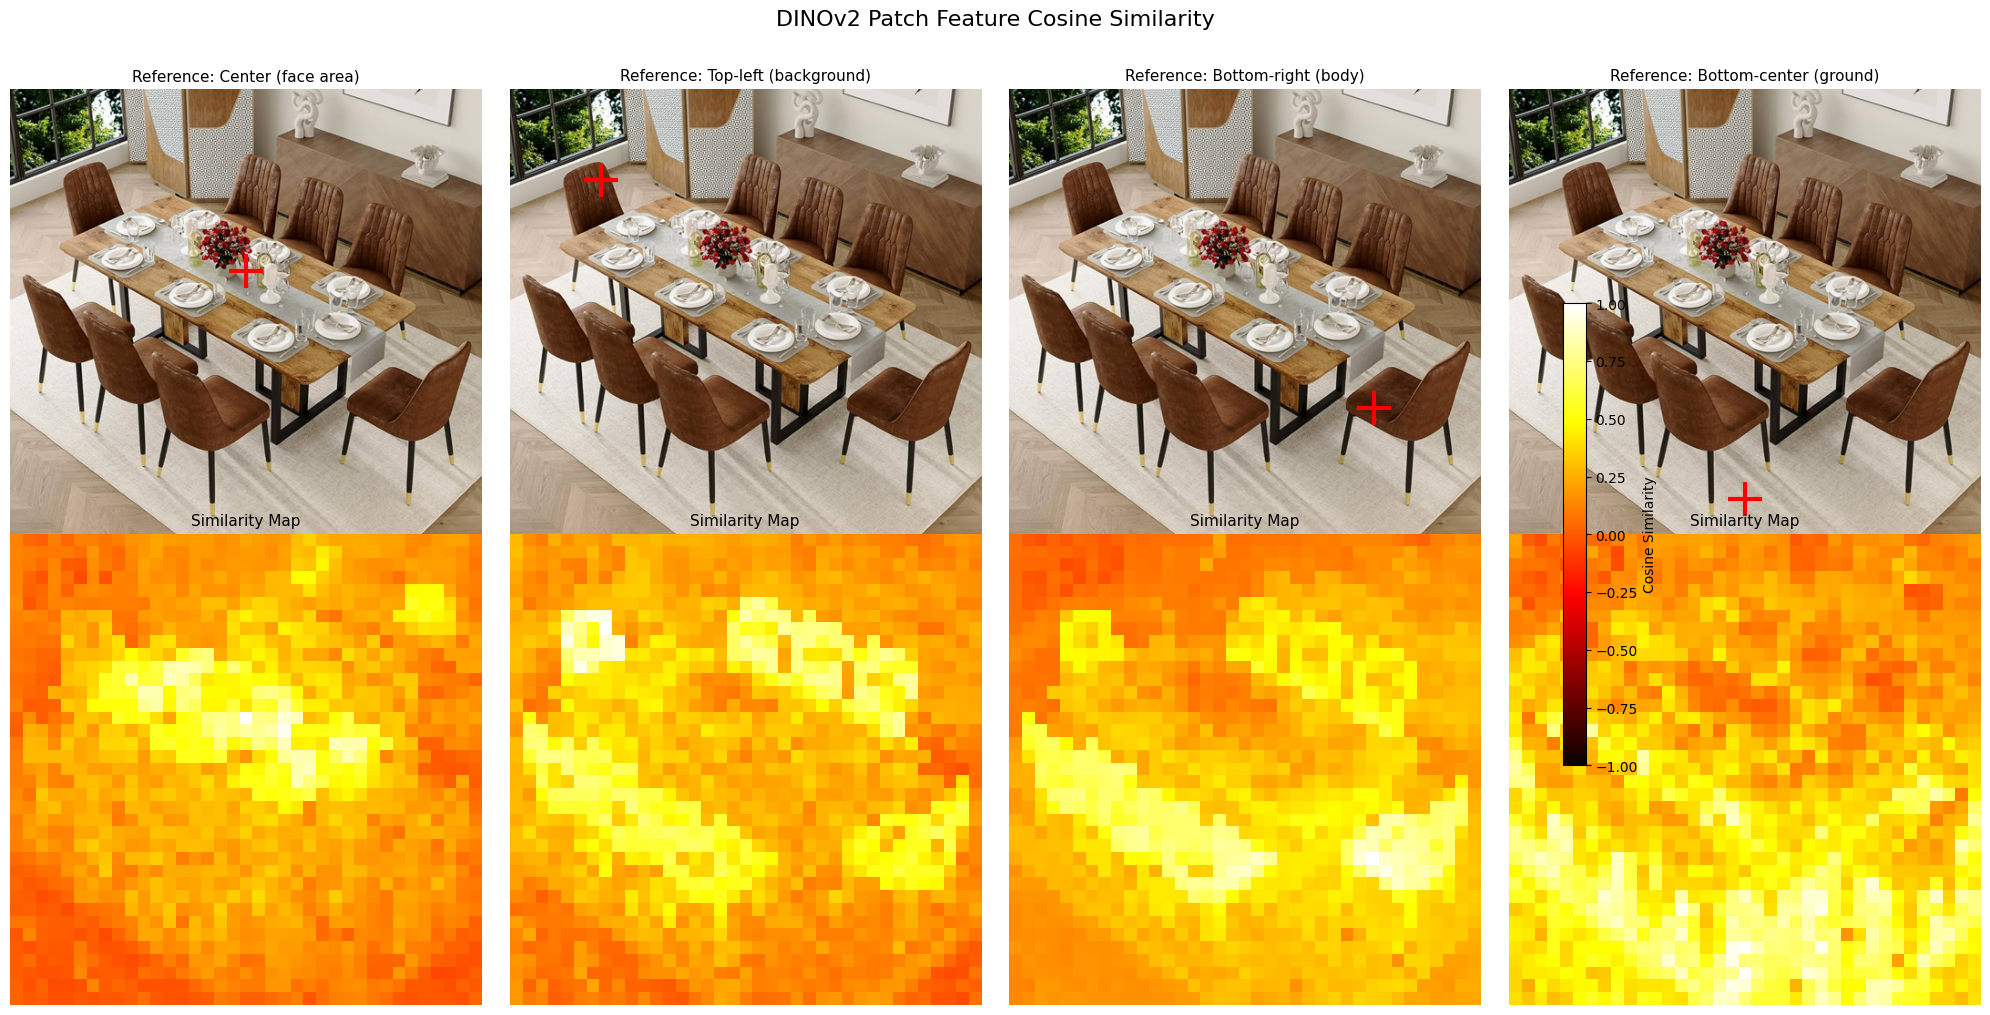

Notice how semantically similar regions (e.g., fur patches, background areas) light up together!


In [17]:
%matplotlib inline
# Static visualization: pick 4 reference points and show similarity maps
# These pixel coordinates correspond to different semantic regions of the image
reference_points = [
    (259, 200, "Center (face area)"),
    (100, 100, "Top-left (background)"),
    (400, 350, "Bottom-right (body)"),
    (259, 450, "Bottom-center (ground)"),
]

display_img = explorer.original_image.resize((518, 518))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (px, py, label) in enumerate(reference_points):
    # Left column: original image with reference point marked
    axes[0, i].imshow(display_img)
    axes[0, i].plot(px, py, 'r+', markersize=25, markeredgewidth=3)
    axes[0, i].set_title(f'Reference: {label}', fontsize=11)
    axes[0, i].axis('off')

    # Right column: cosine similarity heatmap
    patch_idx = explorer.pixel_to_patch(px, py)
    sim_map = explorer.compute_similarity(patch_idx)
    im = axes[1, i].imshow(sim_map, cmap='hot', vmin=-1, vmax=1)
    axes[1, i].set_title(f'Similarity Map', fontsize=11)
    axes[1, i].axis('off')

# Add a single colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6, label='Cosine Similarity')
plt.suptitle('DINOv2 Patch Feature Cosine Similarity', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('dinov2_similarity.pdf', bbox_inches='tight')
plt.show()
print("Notice how semantically similar regions (e.g., fur patches, background areas) light up together!")